# IRLS in CIL: L1 and total-variation regularisation on the simulated sphere

`IRLS` solves an L1-regularised least-squares problem

$$\min_u \; \|Au - b\|_2^2 + \alpha^2 \|Lu\|_1$$

by repeatedly solving a *weighted least-squares* problem instead,

$$\min_u \; \|Au - b\|_2^2 + \alpha^2 \|W_k L u\|_2^2,
\qquad
w_k = \bigl(|Lu_{k-1}|^2 + \tau_k^2\bigr)^{-1/4},$$

each of which an ordinary Krylov solver -- `LSQR` or `CGLS` -- can handle. The
diagonal weights $W_k$ are rebuilt from the current iterate between inner
solves, and the smoothing parameter $\tau_k$ shrinks as the loop proceeds.
Changing $L$ changes the regulariser: $L = I$ gives plain L1, a
`WaveletOperator` gives sparsity in a wavelet basis, and a `GradientOperator`
gives (anisotropic) total variation.

This notebook shows how to set that up, argument by argument, and scores it
against `FISTA` on the same objective. `FISTA` reaches the objective by a
different route -- the proximal map of a non-smooth $g$ -- so it is a useful
independent check on whether IRLS has landed where it should.

Everything that is not about the algorithms -- loading the data, the objective,
the runner, the table and figure formatting -- is in `irls_demo_utils.py`.
Everything about how the algorithms and the regularisation are built stays
here.

In [1]:
%matplotlib inline

from cil.optimisation.algorithms import CGLS, FISTA, IRLS, LSQR
from cil.optimisation.functions import (L1Norm, L1Sparsity, LeastSquares,
                                        TotalVariation)
from cil.optimisation.operators import GradientOperator, WaveletOperator

from irls_demo_utils import (centre_slice, load_and_process_sphere,
                             make_objective, row, run_variants, show_row,
                             table)

DATA = '2d'           # '3d' for the full volume: same code, needs more patience
ANGLE_STEP = 5        # keeps 60 of the 300 projections, so the problem is
                      # under-determined and the regularisation matters
OUTER = 10            # IRLS outer iterations, i.e. reweightings
INNER = 50            # inner Krylov iterations per outer iteration
FISTA_ITERATIONS = OUTER * INNER   # the same number of applications of A

## The data

A simulated sphere phantom from `cil.utilities.dataexample`, converted to
absorption and subsampled in angle by `load_and_process_sphere`. It also
returns an FDK reconstruction, shown throughout as the unregularised reference;
it is *not* where anything starts.

FDK recon

Input Data:
	angle: 60
	horizontal: 128

Reconstruction Volume:
	horizontal_y: 128
	horizontal_x: 128

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 8
	Filter_inplace: False



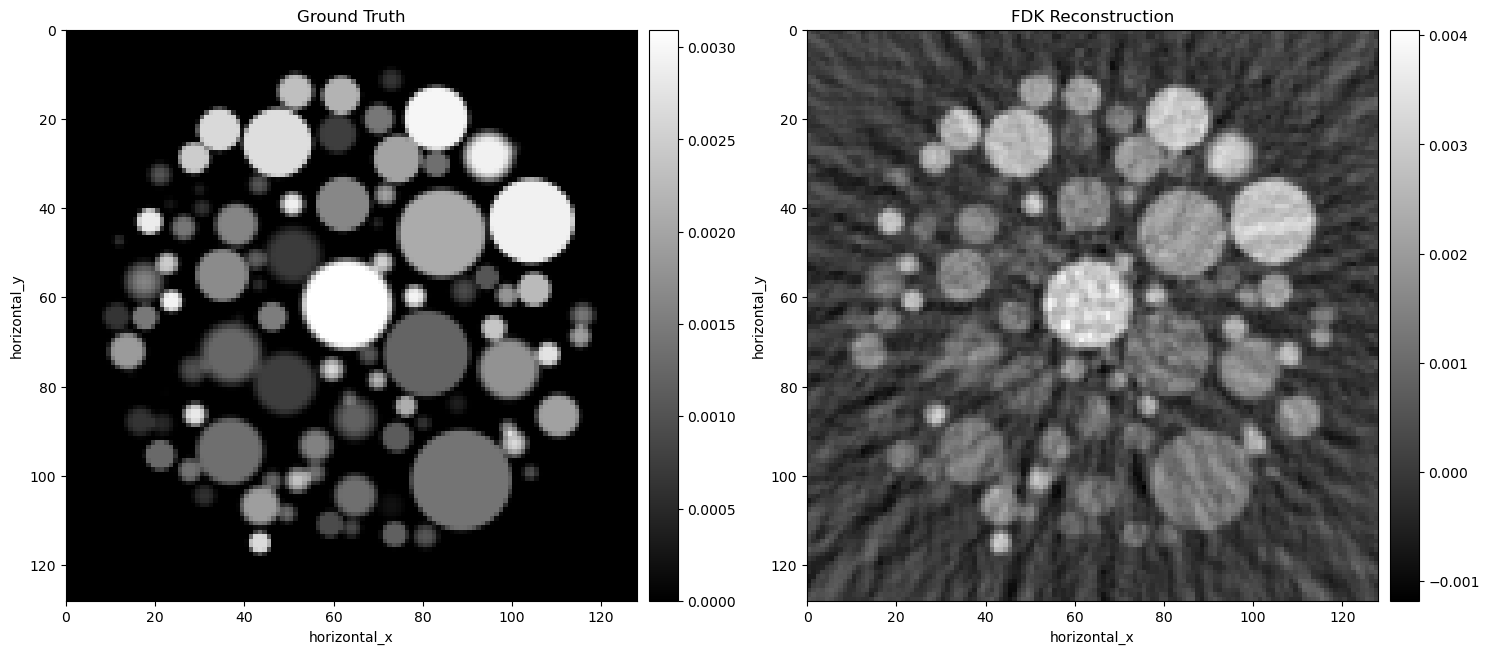

In [2]:
data, A, ig, ground_truth, fdk = load_and_process_sphere(
    angle_step=ANGLE_STEP, single_slice=(DATA == '2d'))

norm_A = A.norm()

# Both methods start from zero, so nothing below is inheriting an FDK.
initial = A.domain_geometry().allocate(0)

# What to draw: the container itself in 2D, its central slice in 3D.
display = None if DATA == '2d' else centre_slice
SUFFIX = '' if DATA == '2d' else ' (central slice)'

## 1. The regularising operator $L$

$L$ is the only thing that has to change to change the regulariser. IRLS
reweights *every entry of* $\mathrm{Range}(L)$ independently, so:

| $L$ | penalty $\|Lu\|_1$ | in CIL |
|---|---|---|
| identity (`None`) | $\sum_i \lvert u_i \rvert$, plain L1 | pass `struct_operator=None` |
| wavelet transform | sparsity of the wavelet coefficients | `WaveletOperator` |
| gradient | $\sum_i \lvert (\nabla u)_i \rvert$, **anisotropic** TV | `GradientOperator` |

The gradient case is anisotropic, not isotropic: the two partial derivatives
are separate entries of $\mathrm{Range}(L)$ and are reweighted independently,
where isotropic TV would couple them through a pointwise 2-norm. That is why
the FISTA comparison below uses `TotalVariation(isotropic=False)` -- matching
the penalty is what makes the two numbers comparable.

In [3]:
# db4 needs bnd_cond='periodization'. WaveletOperator with the default
# 'symmetric' fails LinearOperator.dot_test for every filter longer than haar --
# its direct and adjoint are not an adjoint pair. Periodisation also keeps the
# range the same size as the domain.
haar = WaveletOperator(ig, wname='haar', level=2)
db4 = WaveletOperator(ig, wname='db4', level=2, bnd_cond='periodization')
gradient = GradientOperator(ig)

for name, L in [('identity', None), ('Haar', haar), ('Db4', db4),
                ('gradient', gradient)]:
    print('{:<10} orthogonal: {}'.format(
        name, True if L is None else L.is_orthogonal()))

identity   orthogonal: True
Haar       orthogonal: True
Db4        orthogonal: True
gradient   orthogonal: False


## 2. Setting up IRLS, argument by argument

IRLS is an *outer* loop around an inner solver. The inner solver owns the
problem -- the forward operator, the data, $\alpha$, $L$ and the weights -- and
IRLS owns only the reweighting. So it is built in two steps.

**Step one: the inner solver.** `LSQR` or `CGLS`, with the regularisation
described through its own arguments:

| argument | what it does |
|---|---|
| `operator`, `data` | the forward model $A$ and the measured $b$ |
| `initial` | where the *first* inner solve starts; also the point the first weights are computed from |
| `alpha` | the regularisation weight $\alpha$ |
| `struct_operator` | $L$. `None` means the identity, i.e. plain L1 |
| `form` | how $\alpha W L$ enters the system -- see section 3 |
| `weighted=True` | allocate the weights $W$ up front, in `set_up`, so that the outer loop can rewrite them without allocating |

**Step two: wrap it.** `IRLS(inner_solver=..., max_inner_iteration=...)`
attaches to that solver, allocates whatever it still needs, and from then on an
outer iteration allocates nothing: read the iterate, recompute $W$, warm start,
run the inner solver again.

`weighted=True` matters. Without it the solver is built unweighted and IRLS has
to add the weights when it attaches, which works but pays for the containers
later than it needs to.

In [4]:
inner = CGLS(
    initial=initial,       # zero: the first weights come from here
    operator=A,            # the forward model
    data=data,             # the measured projections
    alpha=0.8,             # the regularisation weight
    struct_operator=haar,  # L: sparsity in the Haar basis
    form='auto',           # Auto selects the best form for the problem. 
    weighted=True,         # allocate W in set_up, not on the first reweighting
)

irls = IRLS(
    inner_solver=inner,
    max_inner_iteration=INNER,   # inner iterations per reweighting
    # tau=1.0, tau_factor=0.1,   # the smoothing schedule; these are the defaults
    # tol=1e-4,                  # optional: stop once the outer iterate settles
)

irls.run(OUTER, verbose=1)
haar_solution = irls.get_output().copy()

Outer Loop:   0%|          | 0/10 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

...

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/50 [00:00<?, ?it/s]

`update_objective` above reports the *inner* solver's residual, measured
against a different reweighted operator each outer iteration. It is not a fixed
quantity being minimised, so it is not a convergence signal and not comparable
with FISTA's objective -- which is why everything below is scored from the
outside, with `make_objective`.

external objective: 2.93453e+00
L1 Wavelet (Haar), alpha = 0.8


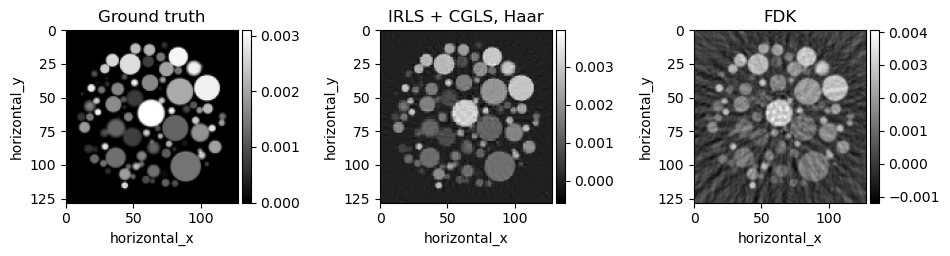

In [5]:
objective = make_objective(A, data, haar, alpha=0.8)
print('external objective: {:.5e}'.format(objective(haar_solution)))

show_row([('Ground truth', ground_truth),
          ('IRLS + CGLS, Haar', haar_solution),
          ('FDK', fdk)],
         'L1 Wavelet (Haar), alpha = 0.8' + SUFFIX, display=display)

## 3. `form`: how the penalty enters the inner system

There are two ways to hand $\alpha W L$ to a Krylov solver, and they are not
interchangeable.

* **`'block'`** solves with the stacked operator
  $K = \begin{bmatrix} A \\ \alpha W L\end{bmatrix}$ against
  $\begin{bmatrix} b \\ 0 \end{bmatrix}$. Always available.
* **`'standard'`** changes variables to $z = WLu$ and solves with
  $A(WL)^{-1}$, which needs $WL$ to be invertible -- in practice $L$
  orthogonal, so that $(WL)^{-1} = L^{\!*}W^{-1}$. Cheaper in memory, since
  there is no block container.

`form='auto'` picks for you, and the rule involves the inner solver as well as
$L$: **LSQR cannot warm start in standard form.** It eliminates $\alpha$ with a
Givens rotation applied to the bidiagonalisation of the residual of $x_0$, so
the penalty lands on the *step* rather than on the solution, which is wrong for
an outer loop that resumes from the previous iterate. CGLS subtracts the
$\alpha^2 x$ term explicitly and warm starts correctly either way. IRLS checks
`inner_solver.supports_warm_start` and forces a reset if it has to, with a
warning.

In [6]:
from cil.optimisation.operators.TikhonovOperator import resolve_form


for solver_class in (LSQR, CGLS):
    for name, L in [('identity', None), ('Haar', haar), ('gradient', gradient)]:
        for zero_initial in (True, False):
            form = resolve_form(
                form='auto',
                solver=solver_class, 
                struct_operator=L,
                zero_initial=zero_initial
            )
            print('zero_initial: {}, solver: {}, L: {} -> {}'.format(
                zero_initial, solver_class.__name__, name, form))

zero_initial: True, solver: LSQR, L: identity -> standard
zero_initial: False, solver: LSQR, L: identity -> block
zero_initial: True, solver: LSQR, L: Haar -> standard
zero_initial: False, solver: LSQR, L: Haar -> block
zero_initial: True, solver: LSQR, L: gradient -> block
zero_initial: False, solver: LSQR, L: gradient -> block
zero_initial: True, solver: CGLS, L: identity -> standard
zero_initial: False, solver: CGLS, L: identity -> standard
zero_initial: True, solver: CGLS, L: Haar -> standard
zero_initial: False, solver: CGLS, L: Haar -> standard
zero_initial: True, solver: CGLS, L: gradient -> block
zero_initial: False, solver: CGLS, L: gradient -> block


## 4. The FISTA reference

FISTA minimises $f(u) + g(u)$ with $f$ smooth and $g$ proximable, so the same
objective splits as

$$f(u) = \|Au - b\|_2^2 \;=\;\texttt{LeastSquares(A, data)},
\qquad
g(u) = \alpha^2 \|Lu\|_1 .$$

Two things to get right, or the two methods are not solving the same problem:

* **`LeastSquares` is $\|Au-b\|^2$ with no factor of a half**, so $g$ carries
  $\alpha$ *squared*, matching the $\alpha^2$ in the IRLS objective.
* **The prox has to be the same penalty**: `L1Sparsity(L)` for an orthogonal
  wavelet $L$, `L1Norm()` for the identity, and `TotalVariation(isotropic=False)`
  for the gradient. Only the last is approximate -- its prox is an inner FGP
  loop rather than a closed form.

The step size is $1/(2\|A\|^2)$, the reciprocal of the Lipschitz constant of
$\nabla f$.

In [7]:
# (name, L, alpha, g): L is the regularising operator, None for the identity;
# g(alpha) is the function whose prox puts FISTA on the same objective.
REGULARISERS = [
    ('L1 Wavelet (Haar)', haar, 1.0, lambda a: a ** 2 * L1Sparsity(haar)),
    ('L1 Wavelet (Db4)', db4, 1.0, lambda a: a ** 2 * L1Sparsity(db4)),
    ('TV', gradient, 2.5, lambda a: a ** 2 * TotalVariation(isotropic=False)),
    ('L1', None, 1.0, lambda a: a ** 2 * L1Norm()),
]

SOLVERS = (LSQR, CGLS)


def build_irls(solver_class, L, alpha, form='auto'):
    """IRLS around an inner Krylov solve of the reweighted problem."""
    inner = solver_class(initial=initial, operator=A, data=data, alpha=alpha,
                         struct_operator=L,
                         form=form)
    return IRLS(inner_solver=inner, max_inner_iteration=INNER)


def build_fista(g, alpha):
    """FISTA on the same objective; g comes from REGULARISERS."""
    return FISTA(initial=initial, f=LeastSquares(A, data), g=g(alpha))

## 5. The regularisers side by side

Each row is one regulariser: IRLS with each inner solver, and FISTA on the same
objective, all scored externally. The alphas are per-regulariser, chosen for
this phantom; they are not comparable across rows.


--- L1 Wavelet (Haar) (alpha = 1.0) ---
Time taken for IRLS + LSQR (block) (L1 Wavelet (Haar)): 3.13 seconds
  IRLS + LSQR (block) (L1 Wavelet (Haar))      objective 4.54703e+00  rmse 1.4810e-01
Time taken for IRLS + CGLS (standard) (L1 Wavelet (Haar)): 2.82 seconds
  IRLS + CGLS (standard) (L1 Wavelet (Haar))   objective 4.53285e+00  rmse 1.4690e-01
Time taken for FISTA (L1 Wavelet (Haar)): 4.47 seconds
  FISTA (L1 Wavelet (Haar))                    objective 4.41479e+00  rmse 1.5472e-01
L1 Wavelet (Haar), alpha = 1.00e+00


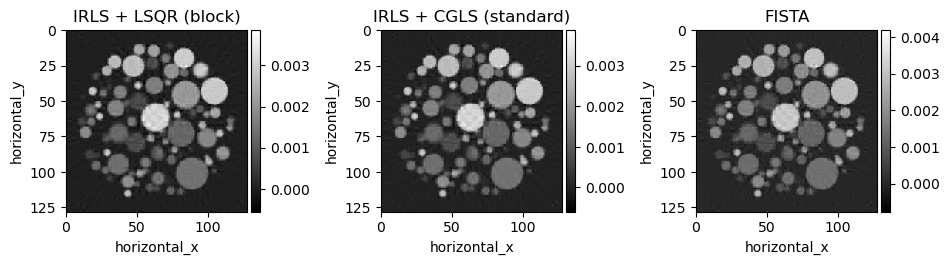


--- L1 Wavelet (Db4) (alpha = 1.0) ---
Time taken for IRLS + LSQR (block) (L1 Wavelet (Db4)): 3.46 seconds
  IRLS + LSQR (block) (L1 Wavelet (Db4))       objective 4.22348e+00  rmse 1.2573e-01
Time taken for IRLS + CGLS (standard) (L1 Wavelet (Db4)): 3.11 seconds
  IRLS + CGLS (standard) (L1 Wavelet (Db4))    objective 4.21247e+00  rmse 1.2662e-01
Time taken for FISTA (L1 Wavelet (Db4)): 4.55 seconds
  FISTA (L1 Wavelet (Db4))                     objective 4.08322e+00  rmse 1.3601e-01
L1 Wavelet (Db4), alpha = 1.00e+00


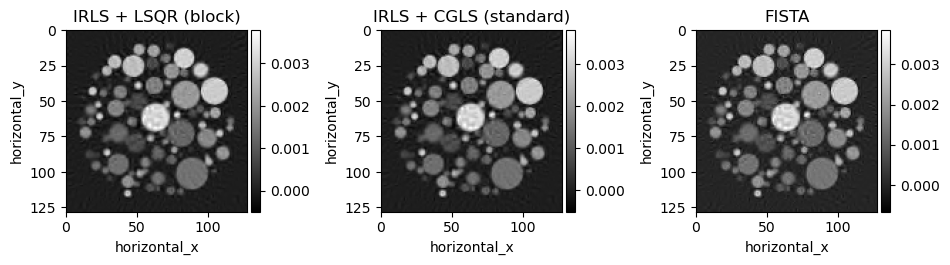


--- TV (alpha = 2.5) ---
Time taken for IRLS + LSQR (block) (TV): 2.72 seconds
  IRLS + LSQR (block) (TV)                     objective 1.84735e+00  rmse 6.1938e-02
Time taken for IRLS + CGLS (block) (TV): 2.38 seconds
  IRLS + CGLS (block) (TV)                     objective 1.84737e+00  rmse 6.1942e-02
Time taken for FISTA (TV): 11.01 seconds
  FISTA (TV)                                   objective 1.78629e+00  rmse 6.9743e-02
TV, alpha = 2.50e+00


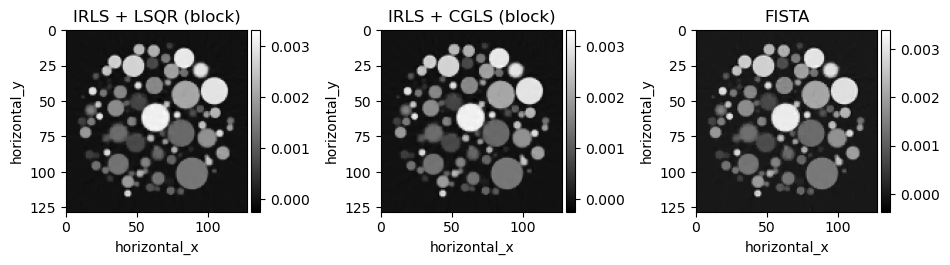


--- L1 (alpha = 1.0) ---
Time taken for IRLS + LSQR (block) (L1): 2.35 seconds
  IRLS + LSQR (block) (L1)                     objective 9.07851e+00  rmse 1.2284e-01
Time taken for IRLS + CGLS (standard) (L1): 2.03 seconds
  IRLS + CGLS (standard) (L1)                  objective 9.06150e+00  rmse 1.4869e-01
Time taken for FISTA (L1): 3.14 seconds
  FISTA (L1)                                   objective 9.04052e+00  rmse 1.6607e-01
L1, alpha = 1.00e+00


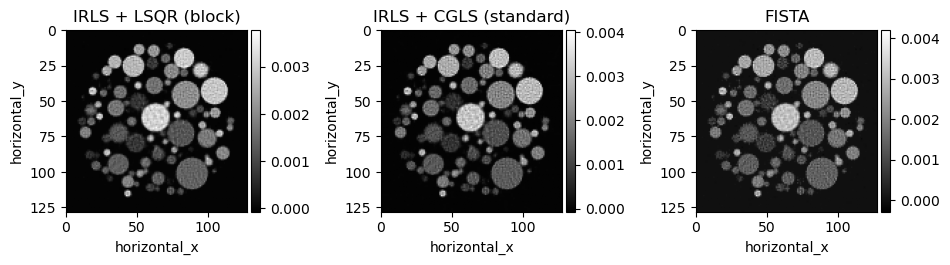


regulariser        alpha  method                  objective    rmse      
-----------------  -----  ----------------------  -----------  ----------
L1 Wavelet (Haar)  1      IRLS + LSQR (block)     4.54703e+00  1.4810e-01
L1 Wavelet (Haar)  1      IRLS + CGLS (standard)  4.53285e+00  1.4690e-01
L1 Wavelet (Haar)  1      FISTA                   4.41479e+00  1.5472e-01
L1 Wavelet (Db4)   1      IRLS + LSQR (block)     4.22348e+00  1.2573e-01
L1 Wavelet (Db4)   1      IRLS + CGLS (standard)  4.21247e+00  1.2662e-01
L1 Wavelet (Db4)   1      FISTA                   4.08322e+00  1.3601e-01
TV                 2.5    IRLS + LSQR (block)     1.84735e+00  6.1938e-02
TV                 2.5    IRLS + CGLS (block)     1.84737e+00  6.1942e-02
TV                 2.5    FISTA                   1.78629e+00  6.9743e-02
L1                 1      IRLS + LSQR (block)     9.07851e+00  1.2284e-01
L1                 1      IRLS + CGLS (standard)  9.06150e+00  1.4869e-01
L1                 1      FISTA      

In [8]:
rows = []
import time
for name, L, alpha, g in REGULARISERS:
    print('\n--- {} (alpha = {}) ---'.format(name, alpha))
    variants = [('IRLS + {} ({})'.format(solver_class.__name__,
                                         resolve_form(solver=solver_class, struct_operator=L, zero_initial=False)),
                 lambda s=solver_class: build_irls(s, L, alpha), OUTER)
                for solver_class in SOLVERS]
    variants.append(('FISTA', lambda: build_fista(g, alpha), FISTA_ITERATIONS))
    results = run_variants(variants, make_objective(A, data, L, alpha),
                           ground_truth, name)
    rows += [row(result, name, '{:g}'.format(alpha), result.label)
             for result in results]

    show_row([(result.label, result.solution) for result in results],
             '{}, alpha = {:.2e}{}'.format(name, alpha, SUFFIX),
             display=display)

table(rows, ['regulariser', 'alpha', 'method', 'objective', 'rmse'])

## 6. Standard against block

For the regularisers where both forms are available -- $L$ orthogonal, and CGLS
as the inner solver so that warm starting survives the change of variable --
the two forms should reach the same place. 


--- L1 Wavelet (Haar) (alpha = 1.0) ---
Time taken for LSQR block (L1 Wavelet (Haar)): 3.18 seconds
  IRLS + LSQR block (L1 Wavelet (Haar))        objective 4.54703e+00  rmse 1.4810e-01
Time taken for CGLS block (L1 Wavelet (Haar)): 3.09 seconds
  IRLS + CGLS block (L1 Wavelet (Haar))        objective 4.54702e+00  rmse 1.4806e-01
Time taken for CGLS standard (L1 Wavelet (Haar)): 2.89 seconds
  IRLS + CGLS standard (L1 Wavelet (Haar))     objective 4.53285e+00  rmse 1.4690e-01
  under CGLS the two forms differ by 1.403e-02, relative
L1 Wavelet (Haar): standard against block, alpha = 1.00e+00


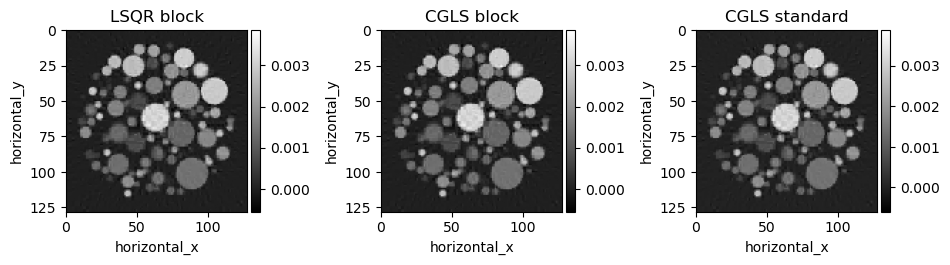


--- L1 Wavelet (Db4) (alpha = 1.0) ---
Time taken for LSQR block (L1 Wavelet (Db4)): 3.28 seconds
  IRLS + LSQR block (L1 Wavelet (Db4))         objective 4.22348e+00  rmse 1.2573e-01
Time taken for CGLS block (L1 Wavelet (Db4)): 3.21 seconds
  IRLS + CGLS block (L1 Wavelet (Db4))         objective 4.22347e+00  rmse 1.2573e-01
Time taken for CGLS standard (L1 Wavelet (Db4)): 3.05 seconds
  IRLS + CGLS standard (L1 Wavelet (Db4))      objective 4.21247e+00  rmse 1.2662e-01
  under CGLS the two forms differ by 1.043e-02, relative
L1 Wavelet (Db4): standard against block, alpha = 1.00e+00


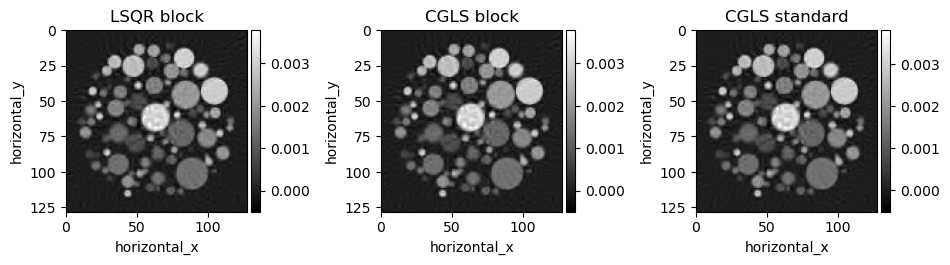


--- L1 (alpha = 1.0) ---
Time taken for LSQR block (L1): 2.30 seconds
  IRLS + LSQR block (L1)                       objective 9.07851e+00  rmse 1.2284e-01
Time taken for CGLS block (L1): 2.35 seconds
  IRLS + CGLS block (L1)                       objective 9.07840e+00  rmse 1.2303e-01
Time taken for CGLS standard (L1): 2.25 seconds
  IRLS + CGLS standard (L1)                    objective 9.06150e+00  rmse 1.4869e-01
  under CGLS the two forms differ by 4.998e-02, relative
L1: standard against block, alpha = 1.00e+00


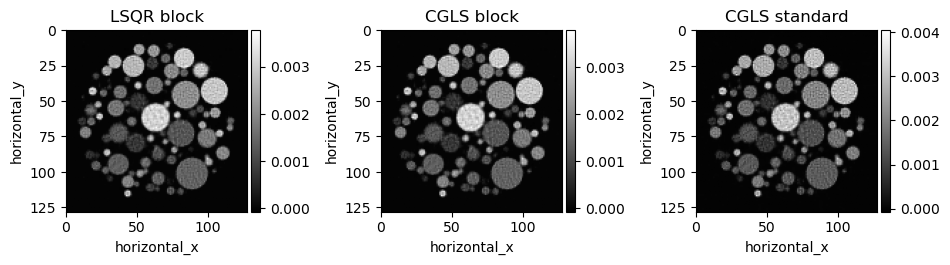


regulariser        inner solver  form                 objective    rmse      
-----------------  ------------  -------------------  -----------  ----------
L1 Wavelet (Haar)  LSQR          block                4.54703e+00  1.4810e-01
L1 Wavelet (Haar)  CGLS          block                4.54702e+00  1.4806e-01
L1 Wavelet (Haar)  CGLS          standard             4.53285e+00  1.4690e-01
L1 Wavelet (Haar)  CGLS          relative difference  1.403e-02              
L1 Wavelet (Db4)   LSQR          block                4.22348e+00  1.2573e-01
L1 Wavelet (Db4)   CGLS          block                4.22347e+00  1.2573e-01
L1 Wavelet (Db4)   CGLS          standard             4.21247e+00  1.2662e-01
L1 Wavelet (Db4)   CGLS          relative difference  1.043e-02              
L1                 LSQR          block                9.07851e+00  1.2284e-01
L1                 CGLS          block                9.07840e+00  1.2303e-01
L1                 CGLS          standard             9.06150e+

In [9]:
combinations = [(solver_class, form)
                for solver_class in SOLVERS for form in ('block', 'standard')
                if not (solver_class is LSQR and form == 'standard')]

rows = []
for name, L, alpha, _ in REGULARISERS:
    if L is not None and not L.is_orthogonal():
        continue
    print('\n--- {} (alpha = {}) ---'.format(name, alpha))
    variants = [('{} {}'.format(solver_class.__name__, form),
                 lambda s=solver_class, f=form: build_irls(s, L, alpha, form=f),
                 OUTER)
                for solver_class, form in combinations]

    results = run_variants(variants, make_objective(A, data, L, alpha),
                           ground_truth, name, prefix='IRLS + ')
    rows += [row(result, name, solver_class.__name__, form)
             for (solver_class, form), result in zip(combinations, results)]

    by_combination = dict(zip(combinations, results))
    block = by_combination[CGLS, 'block'].solution
    standard = by_combination[CGLS, 'standard'].solution
    difference = (block - standard).norm() / max(block.norm(), 1e-30)
    print('  under CGLS the two forms differ by {:.3e}, relative'
          .format(difference))
    rows.append([name, 'CGLS', 'relative difference',
                 '{:.3e}'.format(difference), ''])

    show_row([(result.label, result.solution) for result in results],
             '{}: standard against block, alpha = {:.2e}{}'
             .format(name, alpha, SUFFIX),
             display=display)

table(rows, ['regulariser', 'inner solver', 'form', 'objective', 'rmse'])

## Things to try from here

* **`DATA = '3d'`** in the first cell runs the identical code on the full
  volume. Nothing else changes; `display` switches to the central slice.
* **`alpha`** is the parameter to move first. Too large over-smooths badly --
  on real data TV at $\alpha = 2.5$ is visibly worse than at $\alpha = 0.05$.
* **`tol=1e-4`** on `IRLS` stops the outer loop once the relative change in the
  iterate settles, rather than always running the full count.